In [40]:

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# from ibm_nb import *
from rodeo.ibm import ibm_init
import blackjax

from scipy.integrate import odeint
from jax.config import config
config.update("jax_enable_x64", True)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [161]:
theta = np.array([.2, .2, 3.])
def fitz0(X_t, t, theta=theta):
    a, b, c = theta
    V, R = X_t 
    return jnp.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

def fitz_nb(X, t, theta=theta):
    "FitzHugh-Nagumo ODE function for jax."
    a, b, c = theta
    p = len(X)//2
    V, R = X[0], X[p]
    return jnp.array([c*(V - V*V*V/3 + R),
                      -1/c*(V - a + b*R)])

def fitz_jax(X_t, t, theta=theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:,0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                    [-1/c*(V - a + b*R)]])


In [162]:
tmin = 0.
tmax = 40.
n_obs = 41
theta = np.array([.2, .2, 3.])
x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])
x0 = x0_block.flatten()

# generate obs
ode0 = np.array([-1., 1.])
tseq1 = np.linspace(tmin, tmax, n_obs)
exact = odeint(fitz0, ode0, tseq1)
gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t
y_t = jnp.expand_dims(obs, axis=2)

In [193]:
# ibm prior
n_res = 1
n_steps = int(n_res*(n_obs-1))
tseq = np.linspace(tmin, tmax, n_steps+1)
exact = odeint(fitz0, ode0, tseq)

sigma = 1
sigma = jnp.array([sigma]*2)
n_deriv = jnp.array([3]*2)

dt = (tmax-tmin)/n_steps
ode_init = ibm_init(dt, n_deriv, sigma)
# kinit = indep_init(ode_init, n_deriv)
# ode_init = dict((k, jnp.array(v)) for k, v in kinit.items())
trans_state, mean_state, var_state = ode_init.values()


In [194]:
vv = np.array(list(map(fitz0, exact, tseq)))
X0T = jnp.stack([exact, vv, jnp.zeros((n_steps+1, 2))],axis=2)

In [195]:
def logdensity_fn(X0T, y_t=y_t):
    # X0T = jnp.append(x0_block[None], X1T, axis=0)
    n_steps, n_block, _ = X0T.shape
    n_obs = y_t.shape[0]
    n_res = int((n_steps-1)/(n_obs -1))
    eps = 1e-1
    lp = jnp.sum(stats.norm.logpdf(X0T[0,0], x0_block[0], eps))
    lp += jnp.sum(stats.norm.logpdf(X0T[0,1], x0_block[1], eps))
    lp = 0
    tseq = jnp.linspace(0, 5, n_steps)
    def scan_fun(lp, t):
        ft = fitz_jax(X0T[t], t)
        def vmap_fun(b):
            lp = jnp.sum(stats.norm.logpdf(X0T[t,b], jnp.dot(trans_state[b], X0T[t-1, b]) + mean_state[b], var_state[b]))
            lp += jnp.sum(stats.norm.logpdf(0, X0T[t, b, 1] - ft[b], eps))
            return lp
        lp += jnp.sum(jax.vmap(vmap_fun)(jnp.arange(n_block)))
        return lp, lp
    lp, _ = jax.lax.scan(scan_fun, lp, jnp.arange(1, n_steps))

    def vmap_y(t, b):
        lp = jnp.sum(stats.norm.logpdf(y_t[t, b], X0T[t*n_res, b, 0], gamma))
        return lp
    map_y = jax.vmap(jax.vmap(vmap_y, (0, None)), (None, 0)) 
    lp += jnp.sum(map_y(jnp.arange(0, n_obs), jnp.arange(n_block)))
    return lp

logdensity = lambda x: logdensity_fn(x)

In [196]:
inv_mass_matrix = jnp.ones(n_steps*6+6)*1e-1
num_integration_steps = 100
step_size = 1e-3

hmc = blackjax.nuts(logdensity, step_size, inv_mass_matrix)
initial_position = X0T+1
# initial_position = jnp.repeat(x0_block[np.newaxis, :], n_steps+1, axis=0)[1:]
initial_state = hmc.init(initial_position)
hmc_kernel = jax.jit(hmc.step)

In [197]:
rng_key = jax.random.PRNGKey(0)
new_state, info = hmc.step(rng_key, initial_state)

In [198]:
new_state.position == initial_position

DeviceArray([[[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

             [[False, False, False],
              [False, False, False]],

            

In [199]:
def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states

In [200]:
rng_key = jax.random.PRNGKey(0)
n_samples = 100000
states = inference_loop(rng_key, hmc_kernel, initial_state, n_samples)
samples = states.position

In [201]:
logdensity(samples[-1])

DeviceArray(-380.36029822, dtype=float64)

In [202]:
logdensity(samples[0])

DeviceArray(-124280.05849213, dtype=float64)

In [203]:
samples[0, :, 0, 0]


DeviceArray([ 0.00390376,  2.6044695 ,  2.67045393,  2.51226567,
              2.30268511,  1.90088622, -0.29200997, -0.8463602 ,
             -0.49710195,  0.02717843,  2.51509431,  2.66841399,
              2.51837081,  2.29973327,  1.88665018, -0.39124866,
             -0.83574012, -0.49307086,  0.04965461,  2.55721945,
              2.66083996,  2.50570299,  2.28628738,  1.86751815,
             -0.4803043 , -0.8265016 , -0.48387008,  0.06979432,
              2.59829407,  2.6583874 ,  2.5008049 ,  2.28177823,
              1.85476332, -0.56725318, -0.81972368, -0.47131379,
              0.08749509,  2.63053447,  2.65234476,  2.49606052,
              2.27791278], dtype=float64)

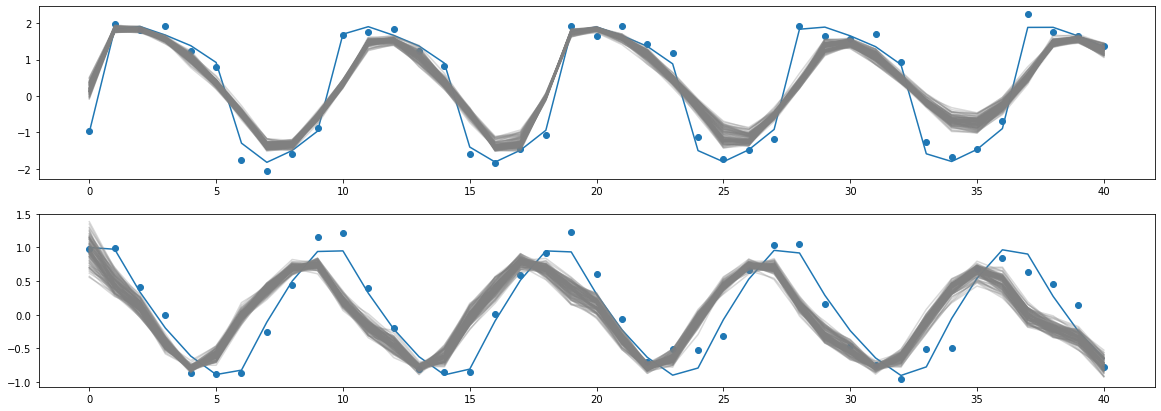

In [204]:
import matplotlib.pyplot as plt
n_dim = 2
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
for i in range(n_dim):
    axs[i].plot(tseq, exact[:, i], label='Exact')
    axs[i].scatter(tseq1, obs[:, i], label='Obs')
    for j in range(100):
        axs[i].plot(tseq, samples[n_samples-j-1, :, i, 0], alpha=0.3, color="grey")